In [1]:
%pip install langchain langchain-groq langchain-community langgraph python-dotenv faiss-cpu pypdf sentence-transformers


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os 

/opt/homebrew/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()


True

In [4]:
class SubState(TypedDict):

    input_text:str
    translated_text:str
    

In [26]:
subgraph_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, groq_api_key=os.getenv("GROQ_API_KEY"))

In [27]:
def translate_text(state:SubState):

    prompt = f""" 
    Translate the following text to Hindi.
    Keep it natural and clear. Do not add extra content.

    Text:{state["input_text"]}
    
    """.strip()

    translated_text=subgraph_llm.invoke(prompt)

    return {'translated_text':translated_text}

In [28]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)

subgraph = subgraph_builder.compile()

In [29]:
class ParentState(TypedDict):

    question:str
    answer_eng:str
    answer_hin:str
    

In [30]:
parent_llm= ChatGroq(model="llama-3.3-70b-versatile",temperature=0, groq_api_key=os.getenv("GROQ_API_KEY"))

In [31]:
def get_answer(state:ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer Clearly.\n\nQuestion:{state['question']}").content
    return{'answer_eng':answer}
    

In [32]:
def translate_text(state:ParentState):
    
    #call the subgraph
    result = subgraph.invoke({'input_text':state['answer_eng']})

    return{'answer_hin': result['translated_text']}

In [33]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", get_answer)
parent_builder.add_node("translate", translate_text)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

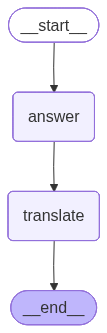

In [34]:
graph = parent_builder.compile()

graph


In [35]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum Physics: A Brief Overview**\n\nQuantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at an atomic and subatomic level. It explores the properties and interactions of particles that are too small to be seen with the naked eye, such as atoms, electrons, and photons.\n\n**Key Principles:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in a way that the state of one object is dependent on the st